# RGB-Phasor Simulations — Color Wheel, Cursors, Clustering, and Unmixing

This tutorial reproduces the RGB-Phasor simulations shown in the paper:  
1) Generate an RGB color wheel,  
2) Map it to the phasor plane,  
3) Use phasor cursors to create masks and pseudocolors,  
4) Cluster the phasor distribution (KMeans),  
5) Demonstrate spectral unmixing with least-squares in phasor space.

> Requires: `numpy`, `matplotlib`, `scikit-learn`, `phasorpy`, and your repo’s `tools.py`.  
If `tools.py` is not available (e.g., when readers run this in Colab), a minimal fallback is provided.

In [1]:
# If running in Colab, uncomment:
# !pip install numpy matplotlib scikit-learn phasorpy scikit-image

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Optional scikit-learn for clustering
from sklearn.cluster import KMeans

# phasorpy: plotting, colors, cursors, and simple phasor from signals
from phasorpy.plot import PhasorPlot
from phasorpy.color import CATEGORICAL
from phasorpy.phasor import phasor_from_signal
from phasorpy.cursors import mask_from_circular_cursor

# Try to import your repo utilities (tools.py). If not found, define light fallbacks.
import sys, os
sys.path.append(os.path.abspath("../../src"))
try:
    import tools  # your repository module
    HAVE_TOOLS = True
except Exception as e:
    print("tools.py not found, using minimal fallbacks:", e)
    HAVE_TOOLS = False

# --- Minimal fallbacks if tools.py is missing ---
def _generate_color_wheel_image(n=256):
    # HSV hue wheel mapped to RGB (simple approximation)
    yy, xx = np.mgrid[0:n, 0:n]
    cx, cy = (n-1)/2, (n-1)/2
    dx, dy = (xx - cx)/(cx), (yy - cy)/(cy)
    r = np.sqrt(dx**2 + dy**2)
    ang = (np.arctan2(dy, dx) + np.pi) / (2*np.pi)  # 0..1
    # HSV -> RGB (value 1 inside unit circle, else nan mask)
    V = (r <= 1.0).astype(float)
    S = V.copy()
    H = ang
    # hsv to rgb
    def hsv2rgb(H, S, V):
        i = np.floor(H*6).astype(int)
        f = H*6 - i
        p = V*(1 - S)
        q = V*(1 - f*S)
        t = V*(1 - (1-f)*S)
        i_mod = i % 6
        r = np.select([i_mod==0, i_mod==1, i_mod==2, i_mod==3, i_mod==4, i_mod==5],
                      [V, q, p, p, t, V], default=0)
        g = np.select([i_mod==0, i_mod==1, i_mod==2, i_mod==3, i_mod==4, i_mod==5],
                      [t, V, V, q, p, p], default=0)
        b = np.select([i_mod==0, i_mod==1, i_mod==2, i_mod==3, i_mod==4, i_mod==5],
                      [p, p, t, V, V, q], default=0)
        return np.stack([r, g, b], axis=-1)
    rgb = hsv2rgb(H, S, V)
    # out-of-circle set to NaN for phasor calc clarity
    rgb[r > 1.0] = np.nan
    return (rgb * 255).astype(np.float32)

def _replace_with_nan(arr):
    return arr  # no-op, provided for API parity

def _rgb2bgr(arr):
    if arr is None: return None
    return arr[..., ::-1]  # swap channels

def _simple_phasor_from_rgb(rgb):
    """Didactic per-pixel phasor: normalize and compute (g,s) ~ (R, G) fractions."""
    arr = rgb / 255.0
    R, G, B = arr[...,0], arr[...,1], arr[...,2]
    denom = (R + G + B + 1e-8)
    g = R / denom
    s = G / denom
    dc = denom  # just to keep return parity
    return dc, g, s

def _map_to_rgb(mask3):
    """Map 3-channel binary mask to RGB (BGR order in your original paper; here we keep RGB)."""
    # mask3: (H, W, 3) int {0,1}
    return np.clip(mask3, 0, 1).astype(float)

# Choose which API to use (your tools or the fallbacks)
generate_color_wheel_image = tools.generate_color_wheel_image if HAVE_TOOLS else _generate_color_wheel_image
replace_with_nan           = tools.replace_with_nan           if HAVE_TOOLS else _replace_with_nan
rgb2bgr                    = tools.rgb2bgr                    if HAVE_TOOLS else _rgb2bgr
map_to_rgb                 = tools.map_to_rgb                 if HAVE_TOOLS else _map_to_rgb
phasor_pixelwise           = tools.phasor                     if HAVE_TOOLS else _simple_phasor_from_rgb

out_dir = Path("../assets/simulations")
out_dir.mkdir(parents=True, exist_ok=True)

dtype: float64
min/max: 0.00023839827461569207 1.0


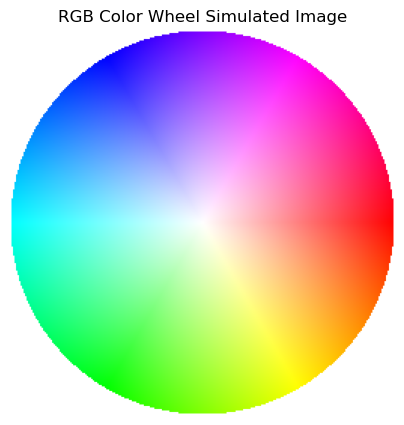

In [2]:
# 1) RGB color wheel (8-bit simulation)
color_wheel_image = generate_color_wheel_image(256)  # shape (256, 256, 3); may include NaNs out-of-circle

import numpy as np
import matplotlib.pyplot as plt

img = color_wheel_image  # what you just generated

# Check dtype and range
print("dtype:", img.dtype)
print("min/max:", np.nanmin(img), np.nanmax(img))

# Normalize and display safely
if img.dtype == np.uint8:
    disp = img
else:
    vmax = np.nanmax(img)
    if vmax is None or np.isnan(vmax):
        vmax = 1.0
    disp = img if vmax <= 1.0 + 1e-6 else img / 255.0

disp = np.nan_to_num(disp, nan=1.0)  # white background for NaNs

plt.figure(figsize=(5,5))
plt.imshow(disp)
plt.axis("off")
plt.title("RGB Color Wheel Simulated Image")
plt.show()

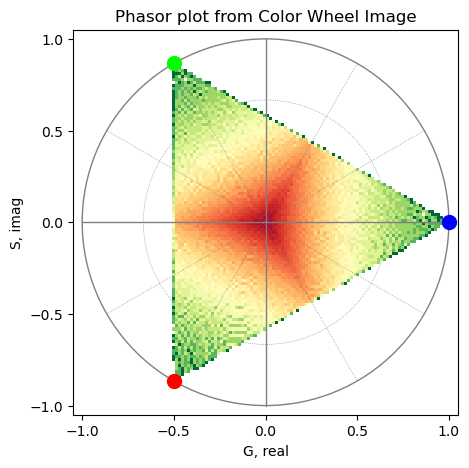

In [3]:
# 2) Compute per-pixel phasor (dc, g, s)
color_wheel_nan = replace_with_nan(color_wheel_image)
aux_bgr = rgb2bgr(color_wheel_nan)  # keep consistent with your paper’s channel ordering if needed

dc, g, s = np.asarray(phasor_pixelwise(aux_bgr))

# Pure RGB components (as “signals”) to show their phasor positions
bgr = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]  # B, G, R in BGR; swap if you prefer RGB
avg, gs, ss = phasor_from_signal(bgr)

plot = PhasorPlot(allquadrants=True, title='')
plot.hist2d(g.flatten(), s.flatten(), cmap="RdYlGn_r")
# Mark the three pure components (adjust colors if you swap channel order)
plot.plot(gs[0], ss[0], color="b", markersize=10)
plot.plot(gs[1], ss[1], color="lime", markersize=10)
plot.plot(gs[2], ss[2], color="r", markersize=10)
plot.fig.set_size_inches(5,5)
plot.ax.set_aspect("equal")
plt.title("Phasor plot from Color Wheel Image")
# plt.savefig(out_dir / "phasor_wheel.png", dpi=150, bbox_inches="tight")
plt.show()

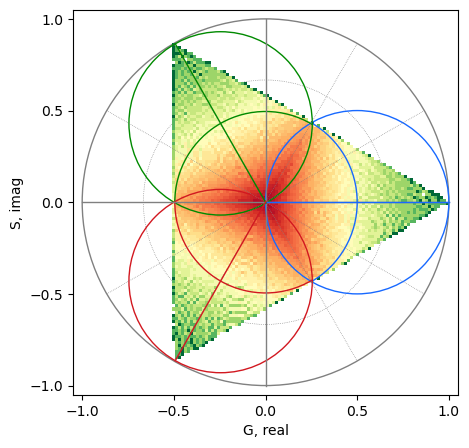

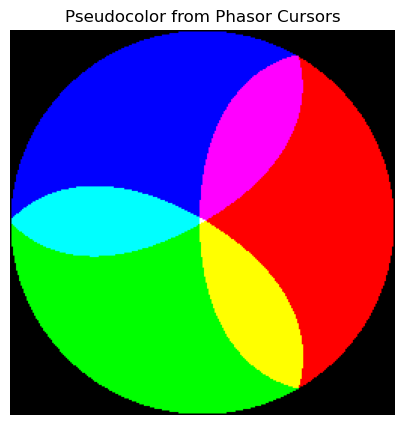

In [4]:
# 3) Cursors on phasor plot
cursors_real = [0.5, -0.245, -0.245]
cursors_imag = [0.0, 0.43, -0.43]
radius = 0.5

plot = PhasorPlot(allquadrants=True, title='')
plot.hist2d(g.flatten(), s.flatten(), cmap="RdYlGn_r")
plot.fig.set_size_inches(5,5)
plot.ax.set_aspect('equal')

# Blue, Green, Red cursors (colors are illustrative)
plot.cursor(cursors_real[0], cursors_imag[0], radius=radius, color=CATEGORICAL[1], linestyle='-')
plot.cursor(cursors_real[1], cursors_imag[1], radius=radius, color=CATEGORICAL[2], linestyle='-')
plot.cursor(cursors_real[2], cursors_imag[2], radius=radius, color=CATEGORICAL[0], linestyle='-')
# plt.savefig(out_dir / "phasor_cursors.png", dpi=150, bbox_inches="tight")
plt.show()

# Mask from cursors (3 channels)
cursors_mask = mask_from_circular_cursor(g, s, cursors_real, cursors_imag, radius=radius)
mask_rgb = np.transpose(cursors_mask, (1, 2, 0)).astype(int)  # (H, W, 3)

# Map to displayable RGB (each cursor region assigned to an RGB primary)
pseudo = map_to_rgb(mask_rgb)

plt.figure(figsize=(5,5))
plt.imshow(pseudo)
plt.axis("off")
plt.title("Pseudocolor from Phasor Cursors")
# plt.savefig(out_dir / "pseudo_from_cursors.png", dpi=150, bbox_inches="tight")
plt.show()

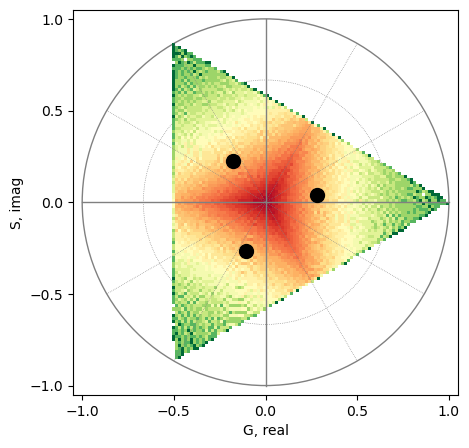

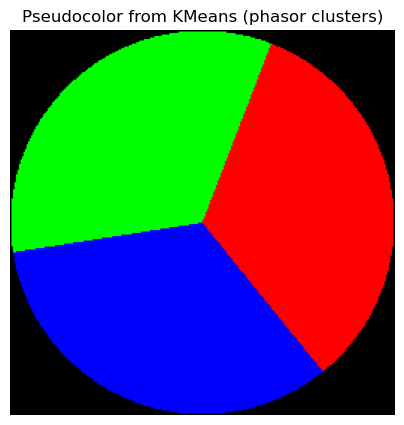

In [5]:
# 4) Clustering (KMeans) on valid phasor points
valid = ~np.isnan(g.flatten()) & ~np.isnan(s.flatten())
X = np.vstack([g.flatten()[valid], s.flatten()[valid]]).T
Xt = np.vstack([g.flatten(), s.flatten()]).T  # includes NaNs (we'll map back carefully)

num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=100, n_init="auto").fit(X)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Simple phasor scatter with cluster centers
plot = PhasorPlot(allquadrants=True, title='')
plot.hist2d(g.flatten(), s.flatten(), cmap="RdYlGn_r")
plot.plot(centers[:,0], centers[:,1], color="k", markersize=10)
plot.fig.set_size_inches(5,5)
plot.ax.set_aspect("equal")
# plt.savefig(out_dir / "phasor_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

# Map labels back to image grid
H, W = g.shape
label_img = np.full(H*W, fill_value=-1, dtype=int)
label_img[valid] = labels
label_img = label_img.reshape(H, W)

# Colorize cluster labels
# Permute to RGB channels for visualization
palette = np.array([
    [1.0, 0.0, 0.0],   # R
    [0.0, 1.0, 0.0],   # G
    [0.0, 0.0, 1.0],   # B
])
vis = np.zeros((H, W, 3), dtype=float)
for k in range(num_clusters):
    vis[label_img == k] = palette[k % len(palette)]

plt.figure(figsize=(5,5))
plt.imshow(vis)
plt.axis("off")
plt.title("Pseudocolor from KMeans (phasor clusters)")
# plt.savefig(out_dir / "pseudo_from_kmeans.png", dpi=150, bbox_inches="tight")
plt.show()

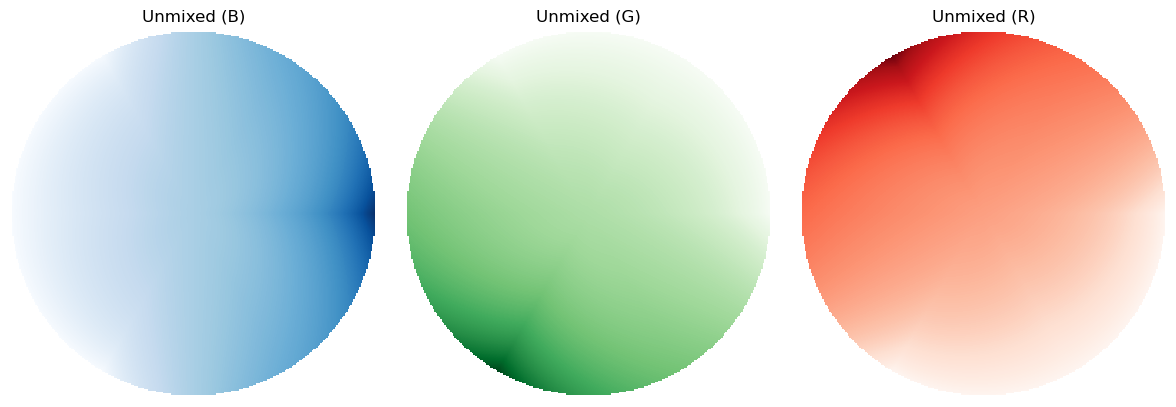

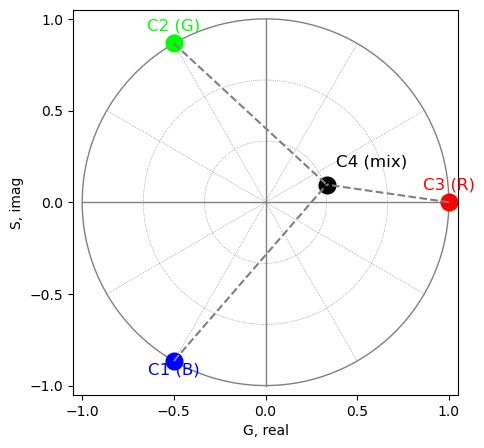

/Users/schutyb/miniforge3/envs/rgb-phasor-env/lib/python3.11/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


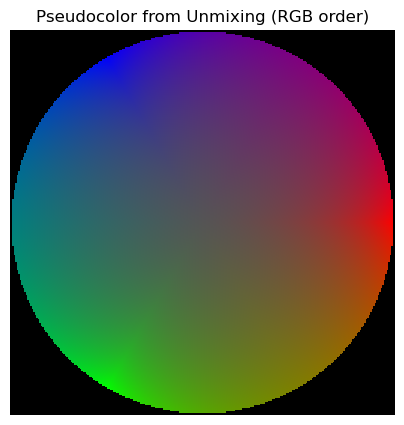

In [6]:
# 5) Spectral unmixing in phasor space (least-squares)
# Define pure components (B,G,R) and one combination C4 (example)
bgr = [[0, 0, 1], [0, 1, 0], [1, 0, 0]]
comb = [1.0, 0.5, 0.3]  # arbitrary linear mixture weights

avg, gs, ss = phasor_from_signal(bgr)
_, gc, sc = phasor_from_signal(comb)

# Build the linear system A * frac = B  where:
# A = [[g_B, g_G, g_R],
#      [s_B, s_G, s_R],
#      [  1 ,   1 ,   1 ]]
# B = [g_px, s_px, 1]
A = np.array([gs, ss, [1, 1, 1]])  # shape (3,3)

# For every pixel phasor (g,s), solve for fractions using least-squares
vecB = np.stack((g, s, np.ones_like(g)), axis=-1)         # (H, W, 3)
B_flat = vecB.reshape(-1, 3).T                            # (3, H*W)
frac_flat, _, _, _ = np.linalg.lstsq(A, B_flat, rcond=None)  # (3, H*W)
frac_img = frac_flat.T.reshape(g.shape + (3,))            # (H, W, 3)

# Visualize each unmixed channel
fig, axs = plt.subplots(1,3, figsize=(12,4))
cmaps = ["Blues", "Greens", "Reds"]
titles = ["Unmixed (B)", "Unmixed (G)", "Unmixed (R)"]
for i in range(3):
    axs[i].imshow(frac_img[..., i], cmap=cmaps[i])
    axs[i].set_title(titles[i]); axs[i].axis("off")
plt.tight_layout()
# plt.savefig(out_dir / "unmixing_channels.png", dpi=150, bbox_inches="tight")
plt.show()

# Show phasor with pure points + combination
plot = PhasorPlot(allquadrants=True, title='')
ax = plot.ax
ax.plot(gs[0], ss[0], 'o', color="b", markersize=12)
ax.plot(gs[1], ss[1], 'o', color="lime", markersize=12)
ax.plot(gs[2], ss[2], 'o', color="r", markersize=12)
ax.plot(gc, sc, 'o', color="k", markersize=12)

for g0, s0 in zip(gs, ss):
    ax.plot([g0, gc], [s0, sc], linestyle='--', color='gray')

ax.text(gs[0], ss[0]-0.07, "C1 (B)", fontsize=12, color='b', ha='center')
ax.text(gs[1], ss[1]+0.07, "C2 (G)", fontsize=12, color='lime', ha='center')
ax.text(gs[2], ss[2]+0.07, "C3 (R)", fontsize=12, color='r', ha='center')
ax.text(gc+0.05, sc+0.1, "C4 (mix)", fontsize=12, color='k', ha='left')

plot.ax.set_xlim(-1.05, 1.05)
plot.ax.set_ylim(-1.05, 1.05)
plot.fig.set_size_inches(5,5)
plot.ax.set_aspect('equal')
# plt.savefig(out_dir / "unmixing_phasor.png", dpi=150, bbox_inches="tight")
plt.show()

# Pseudocolor from fractions (clip to [0,1])
pseudo_unmix = np.clip(frac_img, 0, 1)
plt.figure(figsize=(5,5))
plt.imshow(pseudo_unmix)
plt.axis("off")
plt.title("Pseudocolor from Unmixing (RGB order)")
# plt.savefig(out_dir / "unmixing_rgb.png", dpi=150, bbox_inches="tight")
plt.show()

**Notes.**
- Channel ordering (RGB vs BGR) matters when labeling pure components; keep it consistent with your paper’s convention.
- Least-squares unmixing assumes linearity in phasor space and may require constraints or re-scaling depending on acquisition.
- You can export figures to `docs/assets/simulations/` and embed them in the Theory/Overview page if desired.